# **1. Perkenalan Dataset**


Dataset yang digunakan adalah Teen Social Media and Mental Health Dataset. Dataset ini berisi 1.200 data remaja dengan berbagai atribut yang berkaitan dengan penggunaan media sosial dan kondisi kesehatan mental.

Beberapa fitur yang tersedia antara lain usia, jenis kelamin, durasi penggunaan media sosial harian, kualitas tidur, waktu penggunaan layar sebelum tidur, aktivitas fisik, tingkat interaksi sosial, tingkat stres, tingkat kecemasan, tingkat kecanduan media sosial, serta label depresi.

Tujuan analisis adalah untuk memahami hubungan antara penggunaan media sosial dengan kondisi kesehatan mental remaja serta mempersiapkan data untuk pembangunan model machine learning yang dapat memprediksi risiko depresi.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [24]:
#Type your code here
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [25]:
#Type your code here
# The previous attempt to load 'teenager_mental_healy.csv' failed because the file was not found in the dataset.
# Let's list the contents of the dataset to find the correct filename.
import os
dataset_path = '/kaggle/input/teenager-menthal-healy'
print(f"Files available in the dataset at {dataset_path}:")
available_files = os.listdir(dataset_path)
for file_name in available_files:
    print(f"- {file_name}")

# Please identify the correct filename from the list above and update the 'file_path' variable below.
# Once updated, uncomment the lines related to 'df = kagglehub.load_dataset(...)' and 'df.head()'
file_path = "Teen_Mental_Health_Dataset.csv" # <--- Updated with the correct filename from the list above!

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "algozee/teenager-menthal-healy",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df.head()

Files available in the dataset at /kaggle/input/teenager-menthal-healy:
- Teen_Mental_Health_Dataset.csv


/tmp/ipykernel_628/2757821022.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'teenager-menthal-healy' dataset.


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [26]:
print(df.shape)

(1200, 13)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [27]:
#Type your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [28]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [29]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [30]:
df.duplicated().sum()

np.int64(0)

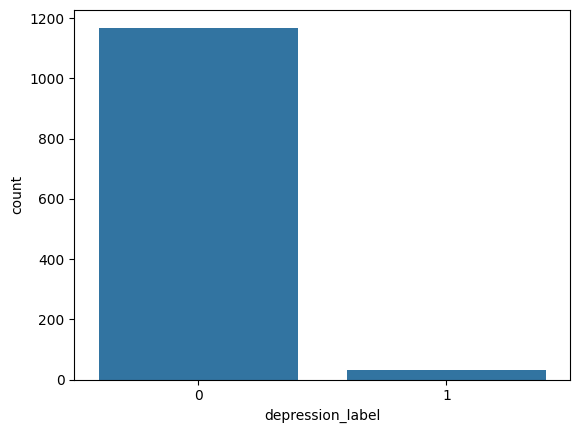

In [31]:
sns.countplot(
    data=df,
    x="depression_label"
)
plt.show()

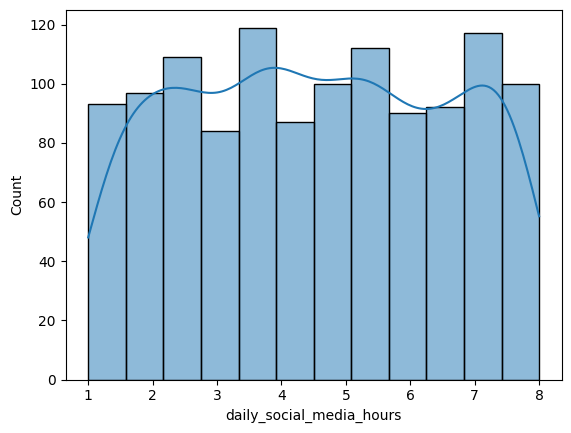

In [32]:
sns.histplot(
  df['daily_social_media_hours'],
  kde=True
)
plt.show()

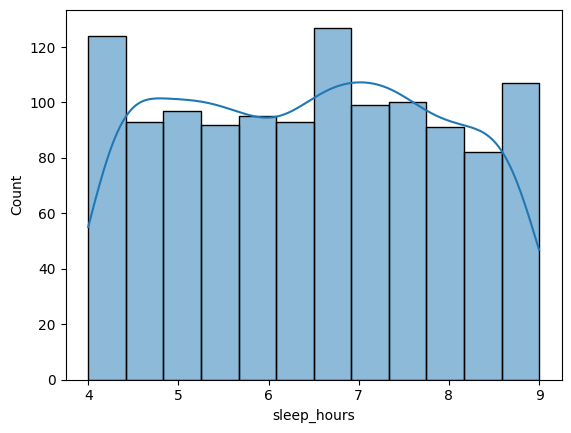

In [33]:
sns.histplot(
  df['sleep_hours'],
  kde=True
)
plt.show()

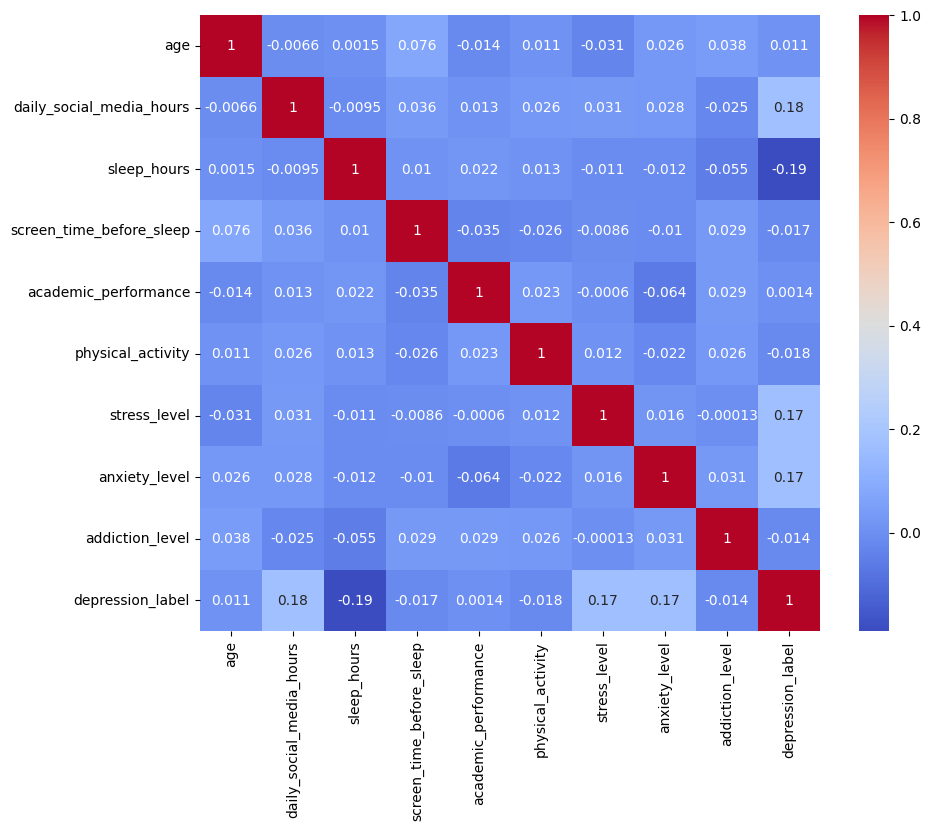

In [34]:
# korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [35]:
# memisahkan fitur target
X = df.drop('depression_label', axis=1)

y = df['depression_label']

In [37]:
encoder = LabelEncoder()

X['gender'] = encoder.fit_transform(X['gender'])

X['platform_usage'] = encoder.fit_transform(
    X['platform_usage']
)

X['social_interaction_level'] = encoder.fit_transform(
    X['social_interaction_level']
)

In [38]:
# feature scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
# simpan data hasil processing
processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df['depression_label'] = y

processed_df.to_csv(
    'teen_social_media_preprocessed.csv',
    index=False
)